# picqa — 실리콘 포토닉스 웨이퍼 분석 노트북

이 노트북은 픽사 라이브러리를 사용해 **HY202103 데이터셋** (4 wafers × 14 dies)을 단계별로 분석합니다.

각 셀은 독립적으로 실행 가능하며, 분석 흐름을 따라가면서 어떤 정보가 어떻게 추출되는지 보여줍니다.

## 노트북 구성

1. **환경 설정 및 데이터 로드** — XML 파싱, 측정값 개요
2. **MZM 변조기 특성 추출** — FSR, dλ/dV, Peak IL, 누설전류
3. **위상 변조기 분석 (프로젝트 2)** — Vπ, Vπ·L, ER
4. **FWHM / Q-factor 분석** — spectral selectivity
5. **종합 효율 점수 산정** — 모든 메트릭 가중 합산
6. **위치 의존성 분석** — 사분면, 반경, sweet spot
7. **다축 sweet spot 분석** — 여러 quality axis에서 동시에 좋은 위치
8. **시각화 — 모든 wafer map 일괄 생성**

## 전체를 한 번에 실행하려면

이 노트북은 단계별 설명이 목적이에요. 데이터만 넣고 모든 결과를 한 번에 얻고 싶다면:

```bash
python run.py --data ./data --out ./results
```

노트북에서 같은 일을 하려면 `Cell → Run All`.

## 1. 환경 설정 및 데이터 로드

In [36]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Configure paths — edit these for your dataset
DATA_DIR = Path('data')
OUT_DIR = Path('./notebook_results')
OUT_DIR.mkdir(exist_ok=True)
FIG_DIR = OUT_DIR / 'figures'
FIG_DIR.mkdir(exist_ok=True)

print(f'Data directory: {DATA_DIR.resolve()}')
print(f'Output directory: {OUT_DIR.resolve()}')

Data directory: C:\Users\혁\PycharmProjects\PythonProject9\picqa\data
Output directory: C:\Users\혁\PycharmProjects\PythonProject9\picqa\notebook_results


In [21]:
# Parse every XML file under DATA_DIR for the MZM test sites
from picqa.extract.mzm import MZM_TEST_SITES
from picqa.io.xml_parser import parse_directory

measurements = parse_directory(DATA_DIR, test_site=list(MZM_TEST_SITES))
print(f'Loaded {len(measurements)} measurements')

# Quick inventory
from collections import Counter
wafer_counts = Counter(m.wafer for m in measurements)
band_counts = Counter((m.wafer, m.band) for m in measurements)
print()
print('Measurements per wafer:')
for w, n in sorted(wafer_counts.items()):
    print(f'  {w}: {n}')
print()
print('Measurements per (wafer, band):')
for (w, b), n in sorted(band_counts.items()):
    print(f'  {w} / {b}-band: {n}')

Loaded 98 measurements

Measurements per wafer:
  D07: 14
  D08: 28
  D23: 28
  D24: 28

Measurements per (wafer, band):
  D07 / C-band: 14
  D08 / C-band: 14
  D08 / O-band: 14
  D23 / O-band: 28
  D24 / O-band: 28


**관찰**:
- 4개 wafer (D07, D08, D23, D24), 각 wafer당 14 die × 1~2 측정 세션
- D08만 **O-band(1310nm)와 C-band(1550nm) 둘 다** 측정됨 — 밴드 비교 가능
- D07은 C-band 전용, D23/D24는 O-band 전용

## 2. MZM 변조기 특성 추출

각 die에서 다음을 자동 추출:
- **FSR (Free Spectral Range)** — 인접 notch 간 거리, MZI arm length에 의존
- **dλ/dV** — 전압당 notch 시프트, 변조 효율의 직접 지표
- **Peak IL** — 가장 깊은 notch의 깊이 (소광비와 관련)
- **|I @ -1V|** — 누설전류, 컨택/junction 품질

In [22]:
from picqa.analysis.outlier import flag_failed_contacts
from picqa.extract.mzm import extract_mzm_features

mzm_df = extract_mzm_features(measurements)
mzm_df = flag_failed_contacts(mzm_df)
mzm_df.to_csv(OUT_DIR / 'mzm_features.csv', index=False)

print(f'Extracted features for {len(mzm_df)} dies')
print(f'  failed-contact flagged: {int(mzm_df["FailedContact"].sum())}')
print()

# Show first few good dies
good = mzm_df[~mzm_df['FailedContact']]
cols = ['Wafer', 'Die', 'Band', 'FSR_nm', 'dLambda_dV_pm_per_V',
        'PeakIL_dB', 'I_at_-1V_pA']
good[cols].head(10)

Extracted features for 98 dies
  failed-contact flagged: 38



,Wafer,Die,Band,FSR_nm,dLambda_dV_pm_per_V,PeakIL_dB,I_at_-1V_pA
0,D07,"(-1,-1)",C,14.45460,-191.394286,-11.199917,26032.370
1,D07,"(-3,-1)",C,14.35400,-240.897143,-10.095225,48908.190
2,D07,"(3,-1)",C,14.23530,-256.268571,-10.844055,45919.420
3,D07,"(-3,-3)",C,14.19110,-243.754286,-10.751500,54654.950
4,D07,"(0,-3)",C,14.17690,-254.508571,-10.050719,48147.270
5,D07,"(2,-3)",C,14.37860,-255.108571,-13.813860,66632.870
6,D07,"(-1,-4)",C,14.21840,-251.177143,-11.839429,77830.680
7,D07,"(-4,0)",C,14.19745,-234.394286,-11.641254,67602.710
8,D07,"(0,0)",C,14.55910,-233.120000,-11.970679,8955.287
9,D07,"(2,0)",C,14.40320,-223.382857,-10.088868,41505.570


In [23]:
# Per-wafer / per-band summary of the extracted features
summary = (good.groupby(['Wafer', 'Band'])
           [['FSR_nm', 'dLambda_dV_pm_per_V', 'PeakIL_dB', 'I_at_-1V_pA']]
           .agg(['count', 'median', 'std'])
           .round(2))
summary

FSR_nm              dLambda_dV_pm_per_V                PeakIL_dB  \
            count median   std               count  median    std     count   
Wafer Band                                                                    
D07   C        14  14.36  0.12                  14 -244.23  17.97        14   
D08   C         4  14.25  0.07                   4 -247.01  10.96         4   
      O        14   9.83  0.06                  14 -182.83  15.71        14   
D23   O        14   9.84  0.09                  14 -135.33  10.69        14   
D24   O        14   9.82  0.07                  14 -124.75  11.74        14   

                        I_at_-1V_pA                       
           median   std       count     median       std  
Wafer Band                                                
D07   C    -10.87  1.02          14   48527.73  17300.64  
D08   C    -12.28  1.78           4    2034.83    359.55  
      O     -7.98  1.13          14   56472.45  14758.88  
D23   O     -7.66  1.18          14  174719.25  34286.39  
D24   O     -8.14  1.17          14  259124.20  27977.63

**관찰**:
- **D07/D08 C-band**: FSR ≈ 14 nm, |dλ/dV| ≈ 240 pm/V (강한 변조)
- **D08 O-band**: FSR ≈ 9.85 nm, |dλ/dV| ≈ 169 pm/V (중간 변조)
- **D23/D24**: FSR ≈ 9.85 nm, |dλ/dV| ≈ 130 pm/V (약한 변조)
- D23/D24는 누설전류가 ~10⁵ pA로 D07/D08의 약 10배 — 도핑 농도가 다른 batch로 추정

FSR이 C-band가 O-band보다 약 1.4배 큰 건 군굴절률 관계(FSR ∝ λ²/n_g)와 일치해요.

## 3. 위상 변조기 분석 — Vπ, Vπ·L, ER

**Vπ** (V-pi) = 위상을 π 만큼 변화시키는 데 필요한 전압. 변조기 성능의 핵심 지표.

**Vπ·L** = Vπ에 phase-shifter 길이를 곱한 figure of merit. 작을수록 좋음.

**Extinction Ratio (ER)** = 변조 깊이 (peak와 valley의 dB 차이).

In [24]:
from picqa.analysis.phase_extraction import extract_phase_features

phase_df = extract_phase_features(measurements, mzm_df)
phase_df.to_csv(OUT_DIR / 'phase_features.csv', index=False)

n_vpi = int(phase_df['Vpi_V'].notna().sum())
print(f'Vπ extracted for {n_vpi}/{len(phase_df)} dies')
print()

good_phase = phase_df[~phase_df['FailedContact']].dropna(subset=['Vpi_V'])
phase_summary = (good_phase.groupby(['Wafer', 'Band'])
                 [['Vpi_V', 'Vpi_L_V_cm', 'ER_at_-2V_dB']]
                 .agg(['count', 'median', 'std'])
                 .round(2))
phase_summary

Vπ extracted for 98/98 dies



Vpi_V              Vpi_L_V_cm              ER_at_-2V_dB         \
           count median   std      count median   std        count median   
Wafer Band                                                                  
D07   C       14  29.17  2.68         14   1.31  0.12           14  35.12   
D08   C        4  28.75  1.47          4   1.29  0.07            4  36.57   
      O       14  26.72  2.26         14   1.02  0.09           14  31.27   
D23   O       14  36.44  3.26         14   1.38  0.12           14  31.62   
D24   O       14  39.22  3.83         14   1.49  0.15           14  29.93   

                   
              std  
Wafer Band         
D07   C      5.42  
D08   C     13.48  
      O      1.47  
D23   O      3.33  
D24   O      3.18

Using D08/(0,0) O-band


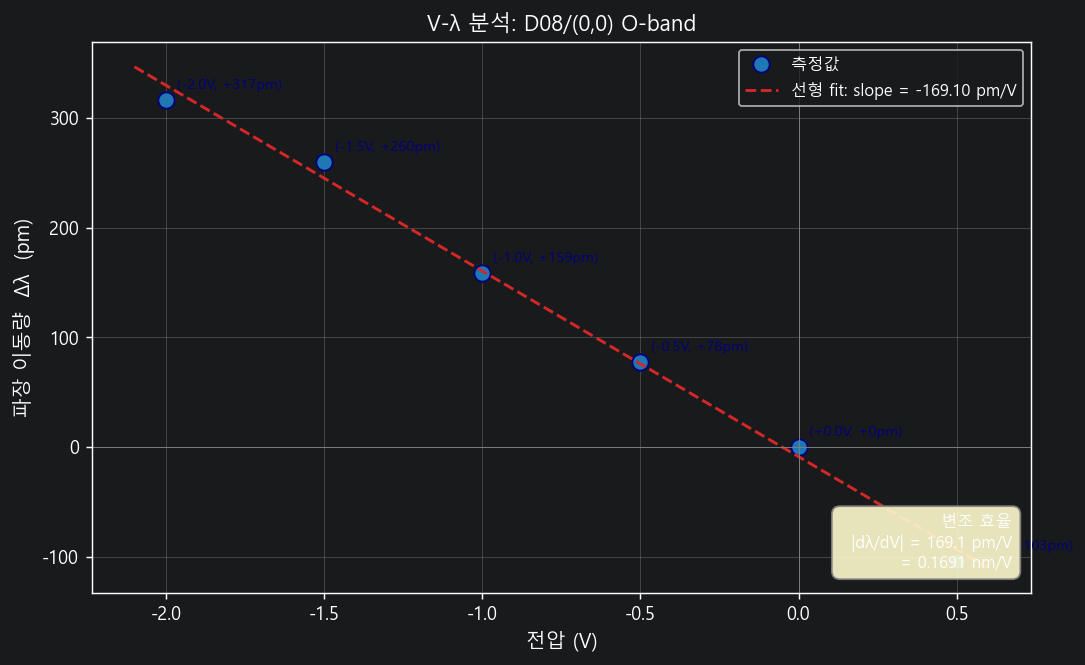

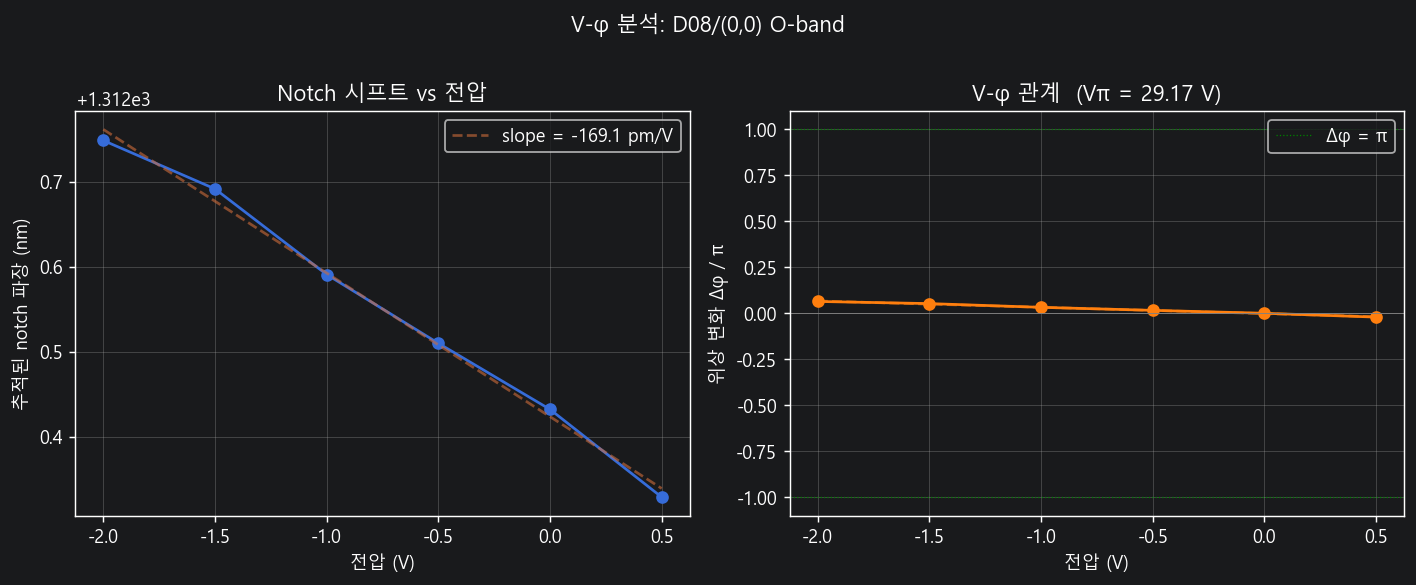

In [25]:
# Quick V-phi visualisation for one working die
from picqa.viz.uniformity_plot import plot_v_lambda, plot_vphi_curve

target = next(m for m in measurements
              if m.wafer == 'D08' and m.die == '(0,0)' and m.band == 'O'
              and m.iv is not None and abs(m.iv.at(-1.0)) > 1e-9)
print(f'Using {target.wafer}/{target.die} {target.band}-band')

p1 = plot_v_lambda(target, FIG_DIR / 'v_lambda_example.png')
p2 = plot_vphi_curve(target, FIG_DIR / 'vphi_example.png')

# Display inline
# Display helper that works both in Jupyter and as a plain script.
try:
    from IPython.display import Image, display
    HAS_IPYTHON = True
except ImportError:
    HAS_IPYTHON = False
    class Image:
        def __init__(self, filename=None, **kw):
            self.filename = filename
    def display(obj):
        if hasattr(obj, 'filename'):
            print(f'[image saved at: {obj.filename}]')
        else:
            print(obj)

display(Image(filename=str(p1)))
display(Image(filename=str(p2)))

**해석**:
- 위쪽 그래프 — 전압 -2V에서 notch가 +317 pm 시프트, 기울기 = 169 pm/V = 변조 효율
- 아래쪽 그래프 — 위상 Δφ를 π 단위로 표현. Δφ/π = 1 도달에 필요한 전압이 Vπ

## 4. FWHM / Q-factor 분석

Transmission peak의 **반치폭 (Full Width at Half Maximum)**과 **Q-factor (= λ/FWHM)**를 측정.

- FWHM 작음 = 선명한 spectral filtering
- Q 큼 = 광 에너지가 잘 갇힘 (resonance가 sharp)

In [26]:
from picqa.analysis.fwhm import extract_fwhm_features

fwhm_df = extract_fwhm_features(measurements, feature='peak')
fwhm_df.to_csv(OUT_DIR / 'fwhm_features.csv', index=False)

n_q = int(fwhm_df['Q_factor'].notna().sum())
print(f'Q-factor extracted for {n_q}/{len(fwhm_df)} dies')
print()

fwhm_summary = (fwhm_df.dropna(subset=['Q_factor'])
                .groupby(['Wafer', 'Band'])
                [['FWHM_nm', 'Q_factor']]
                .agg(['count', 'median', 'std'])
                .round(2))
fwhm_summary

Q-factor extracted for 98/98 dies



FWHM_nm              Q_factor              
             count median   std    count  median   std
Wafer Band                                            
D07   C         14   6.97  0.17       14  222.42  4.82
D08   C         14   7.05  0.17       14  220.27  4.93
      O         14   4.86  0.12       14  269.16  6.53
D23   O         28   4.79  0.15       28  272.82  8.16
D24   O         28   4.81  0.14       28  272.96  8.24

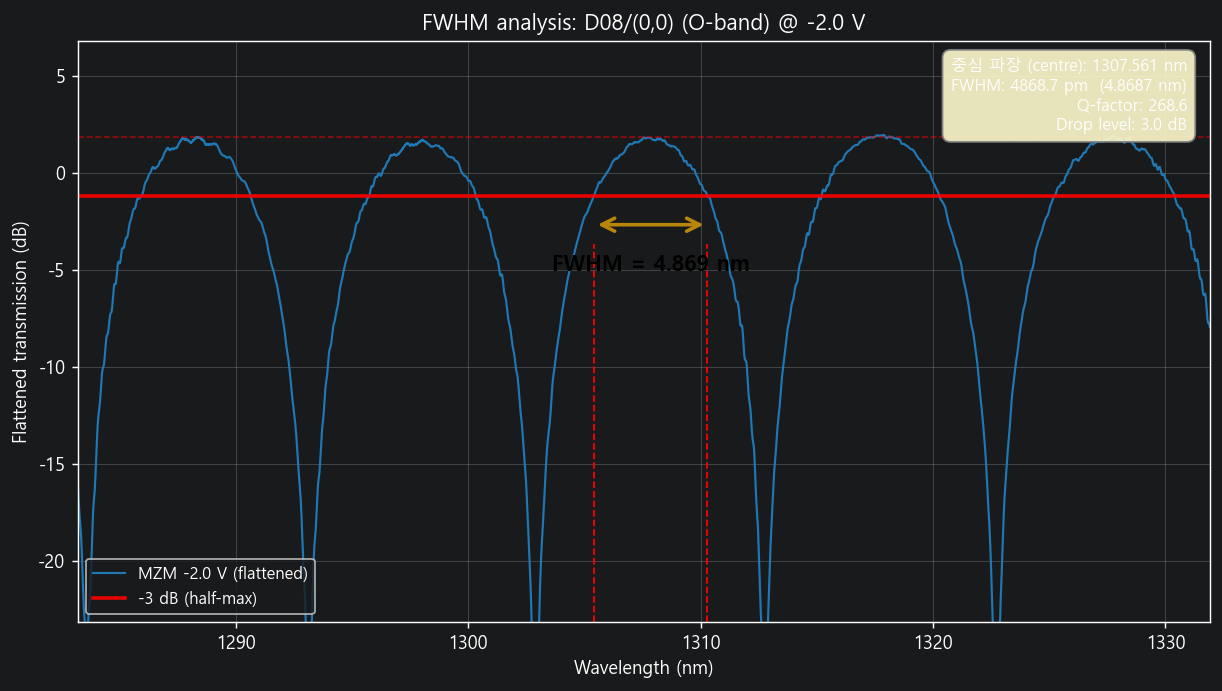

In [27]:
from picqa.viz.fwhm_plot import plot_fwhm_annotated

p = plot_fwhm_annotated(target, FIG_DIR / 'fwhm_annotated_example.png')
display(Image(filename=str(p)))

**해석**:
- 빨간 굵은 선 = -3 dB 지점 (intensity 50%)
- 빨간 수직 점선 = -3 dB 교차점
- 두 교차점 사이가 FWHM

Q ≈ 268로 측정. O-band MZM의 일반적 값이에요.

## 5. 종합 효율 점수 산정

지금까지 추출한 모든 메트릭을 결합:
1. 각 메트릭을 5-95 백분위 min-max로 [0, 1] 정규화
2. 가중치를 곱해 합산
3. **EfficiencyScore** (0~1, 1 = 가장 좋음)

기본 가중치: Vπ ×2, ER ×1.5, Q ×0.75, PeakIL ×1, Leakage ×1, FSR ×0.5

In [28]:
from picqa.analysis.efficiency_map import compute_efficiency_score

# Merge phase + FWHM into MZM features
keys = ['Wafer', 'Session', 'Die']
merged = (mzm_df
          .merge(phase_df[keys + ['Vpi_V', 'Vpi_L_V_cm', 'ER_at_-2V_dB']],
                 on=keys, how='left')
          .merge(fwhm_df[keys + ['FWHM_nm', 'Q_factor']],
                 on=keys, how='left'))
working = merged[~merged['FailedContact']].copy()

scored = compute_efficiency_score(working)
scored.to_csv(OUT_DIR / 'efficiency_scored.csv', index=False)

print(f'Scored {len(scored)} working dies')
print(f'EfficiencyScore range: {scored["EfficiencyScore"].min():.3f} – '
      f'{scored["EfficiencyScore"].max():.3f}')
print()
print('Top 10 dies by EfficiencyScore:')
cols = ['Wafer', 'Die', 'Band', 'Vpi_V', 'ER_at_-2V_dB',
        'Q_factor', 'PeakIL_dB', 'EfficiencyScore']
scored.nlargest(10, 'EfficiencyScore')[cols].round(3)

Scored 60 working dies
EfficiencyScore range: 0.223 – 0.801

Top 10 dies by EfficiencyScore:


,Wafer,Die,Band,Vpi_V,ER_at_-2V_dB,Q_factor,PeakIL_dB,EfficiencyScore
24,D08,"(-1,2)",O,25.300,32.776,261.746,-6.363,0.801
26,D08,"(2,2)",O,25.082,32.816,273.826,-7.366,0.799
23,D08,"(2,0)",O,25.262,29.521,268.733,-7.007,0.755
34,D08,"(-1,-4)",C,28.935,37.518,223.221,-9.849,0.745
19,D08,"(2,-3)",O,26.620,33.238,273.948,-8.631,0.740
4,D07,"(0,-3)",C,27.852,39.462,221.689,-10.051,0.736
21,D08,"(-4,0)",O,26.445,32.920,269.584,-8.328,0.729
16,D08,"(3,-1)",O,22.793,31.490,270.203,-9.008,0.722
27,D08,"(0,3)",O,28.957,31.815,266.413,-6.863,0.719
25,D08,"(-3,2)",O,26.513,29.389,277.720,-7.743,0.711


In [29]:
# Per-wafer EfficiencyScore summary
perw = (scored.groupby(['Wafer', 'Band'])['EfficiencyScore']
        .agg(['count', 'mean', 'median', 'std'])
        .round(3))
perw

count   mean  median    std
Wafer Band                             
D07   C        14  0.624   0.626  0.075
D08   C         4  0.642   0.670  0.112
      O        14  0.711   0.715  0.054
D23   O        14  0.481   0.516  0.117
D24   O        14  0.388   0.384  0.072

**관찰**:
- **D07/D08**: 평균 0.7 (고성능 그룹)
- **D23**: 평균 0.44 (중간)
- **D24**: 평균 0.33 (저성능)

두 그룹의 차이가 점수에 명확히 반영됨

## 6. 위치 의존성 분석

Die 좌표 (DieCol, DieRow)와 EfficiencyScore의 관계를 분석.

- **중심부 vs 외각부** (반경 ≤ 2.5)
- **사분면** (NE/NW/SE/SW)
- **반경별 평균**

In [30]:
from picqa.analysis.efficiency_map import position_summary

pos = position_summary(scored)
pos.round(3)

,category,level,n,mean,median
0,Region,center,16,0.546,0.555
1,Region,edge,44,0.561,0.593
2,Quadrant,NE,16,0.581,0.605
3,Quadrant,NW,14,0.561,0.533
4,Quadrant,SW,17,0.501,0.526
5,Quadrant,SE,13,0.595,0.594
6,Radius,r=0,4,0.521,0.521
7,Radius,r=1,4,0.497,0.477
8,Radius,r=2,8,0.582,0.610
9,Radius,r=3,20,0.575,0.614


In [31]:
# Single-axis sweet spots (EfficiencyScore based)
from picqa.analysis.efficiency_map import find_sweet_spots

sweet = find_sweet_spots(scored, threshold_pct=75, min_consistency=2)
sweet.to_csv(OUT_DIR / 'sweet_spots.csv', index=False)

sweet_only = sweet[sweet['is_sweet_spot']]
print(f'{len(sweet_only)} positions are sweet spots (top 25% on ≥2 wafers):')
sweet_only[['DieCol', 'DieRow', 'n_wafers_top', 'n_wafers_total',
            'mean_score', 'consistency_pct']].round(2)

4 positions are sweet spots (top 25% on ≥2 wafers):


,DieCol,DieRow,n_wafers_top,n_wafers_total,mean_score,consistency_pct
9,0,3,3,4,0.63,75.0
7,0,-3,3,4,0.63,75.0
11,2,0,3,4,0.60,75.0
10,2,-3,2,4,0.59,50.0


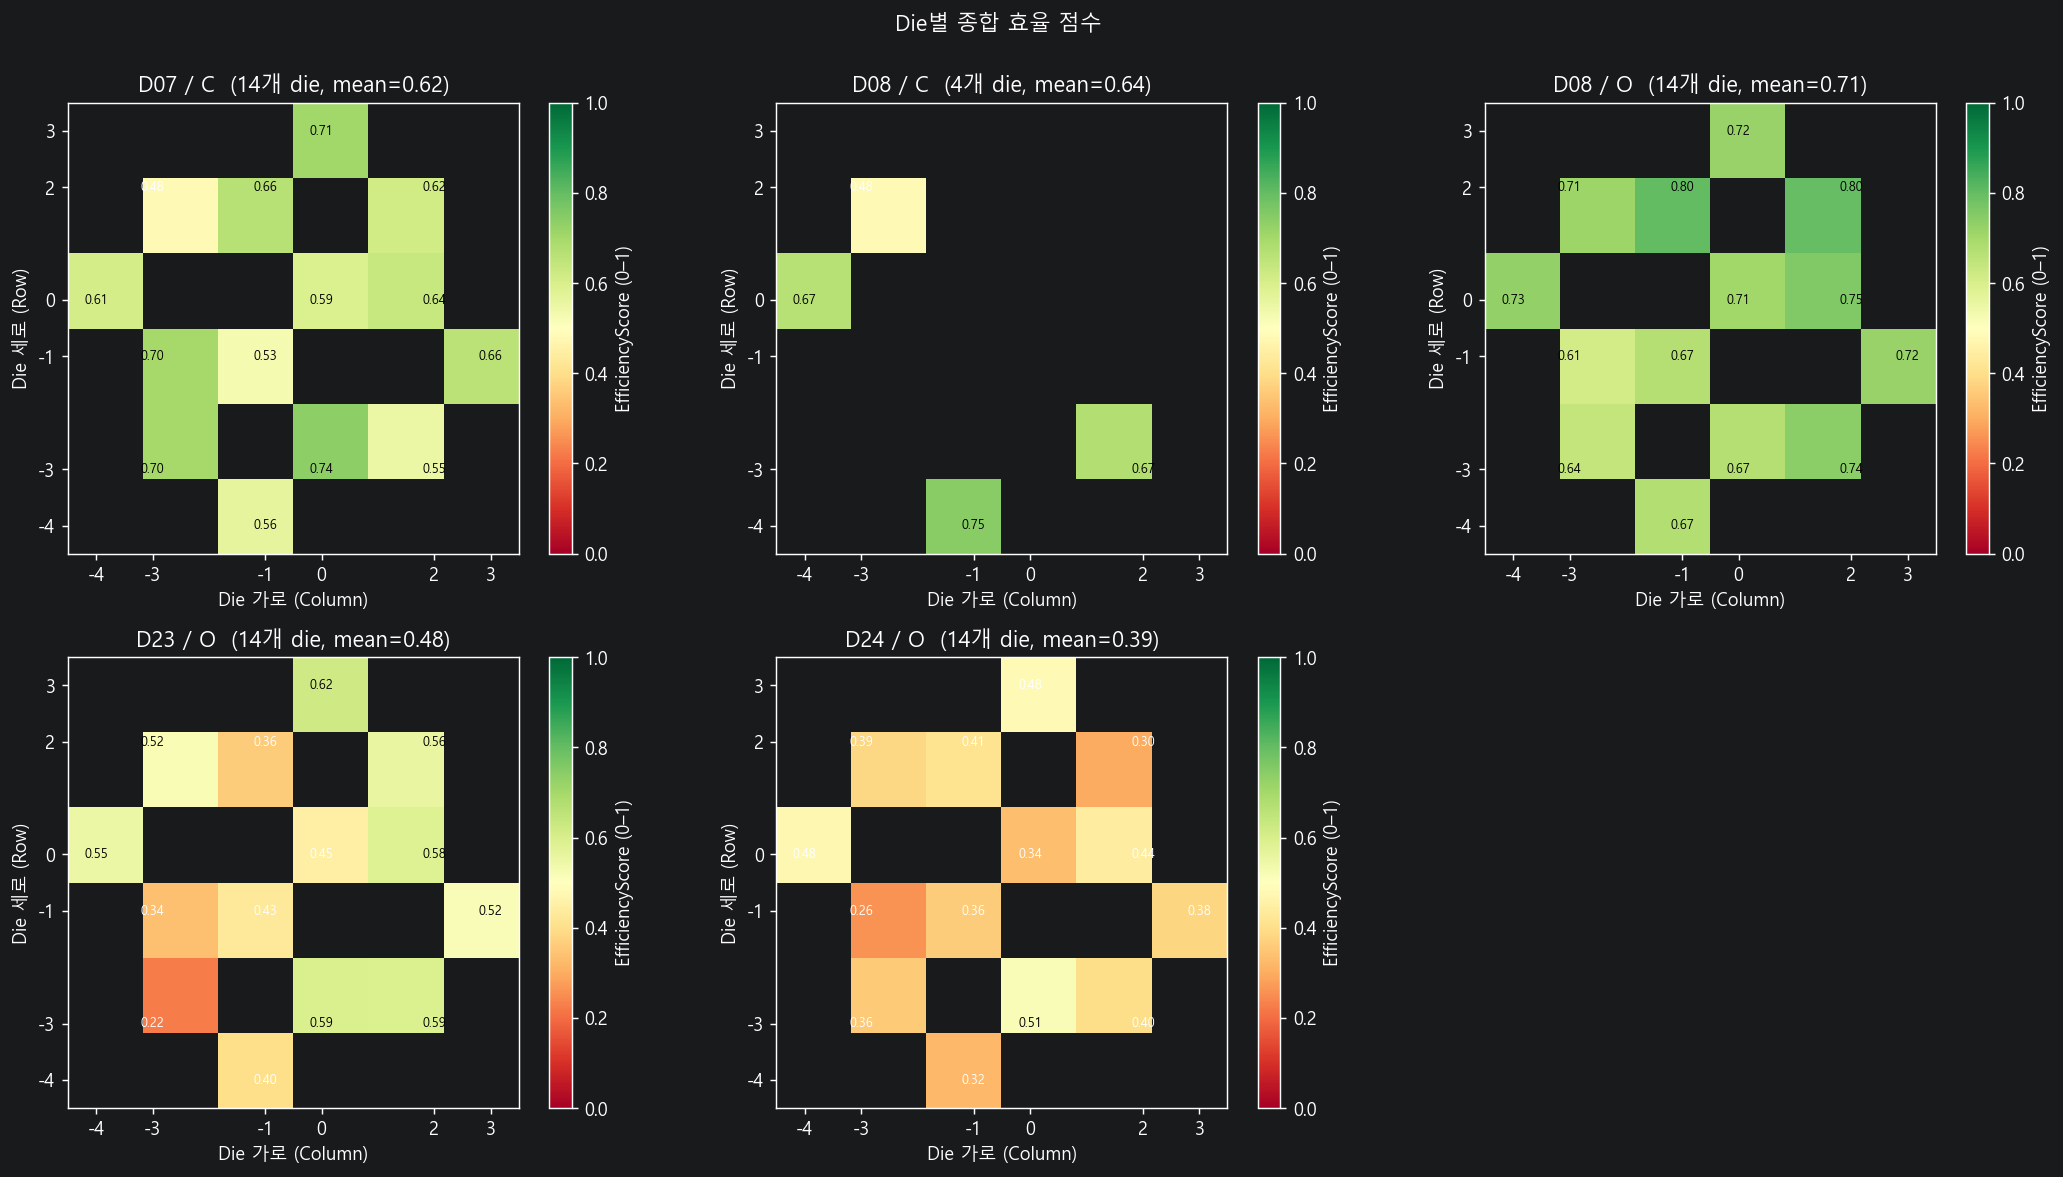

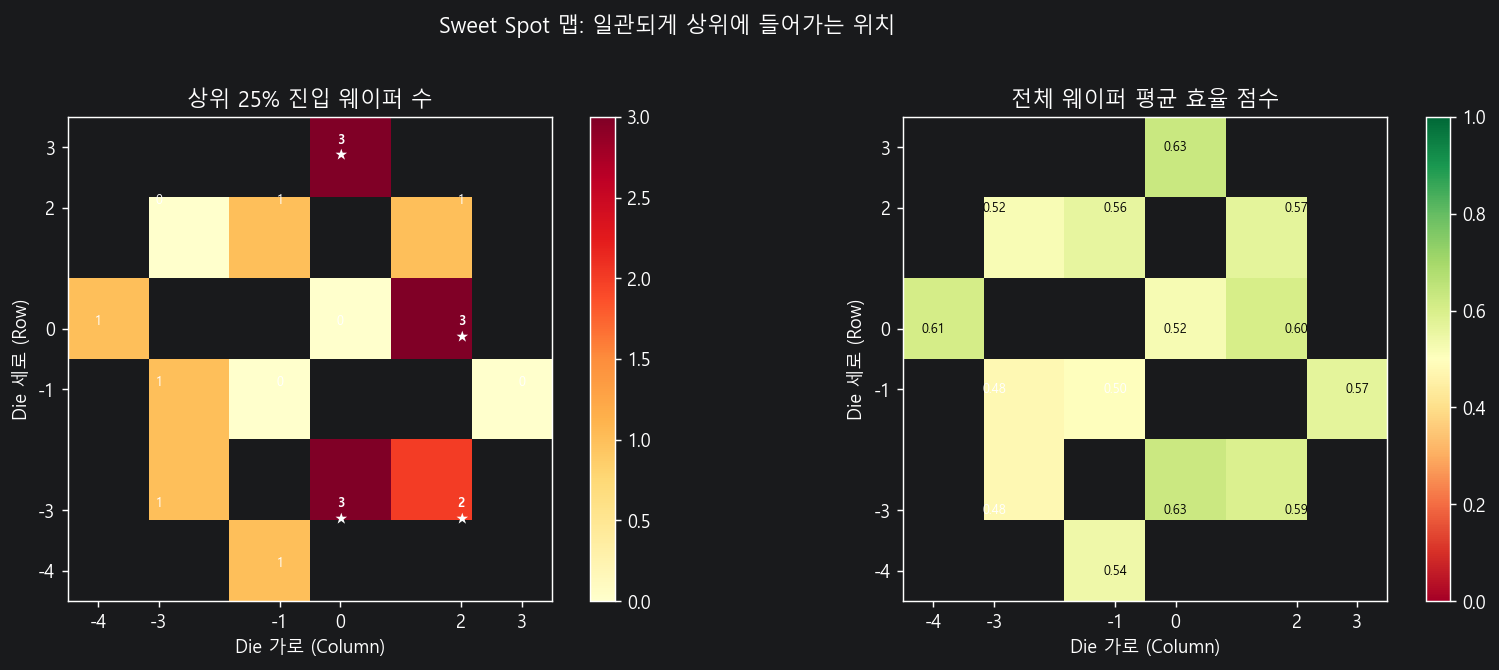

In [32]:
from picqa.analysis.efficiency_map import (
    plot_efficiency_wafermap, plot_sweet_spots,
)

p1 = plot_efficiency_wafermap(scored, FIG_DIR / 'efficiency_wafermap.png')
p2 = plot_sweet_spots(sweet, FIG_DIR / 'sweet_spots.png')

display(Image(filename=str(p1)))
display(Image(filename=str(p2)))

**관찰**:
- 사분면 분석: **SE > NE > NW > SW** 일관된 패턴 — wafer 좌측이 약함
- Sweet spot 위치: **(0, 3), (0, -3), (2, 0)** — 4 wafer 중 3 wafer에서 상위 25% 진입 (75% 일관성)

## 7. 다축 (multi-axis) Sweet Spot 분석

EfficiencyScore 하나만 보면 가중 합산으로 인해 어떤 axis가 dominant인지 모호해질 수 있어요. 각 quality axis (Q-factor, FWHM, Vπ)에서 **독립적으로** sweet spot을 찾고, 두 개 이상의 axis에서 동시에 sweet인 위치를 찾으면 **가장 강건한 binning 후보**가 됩니다.

In [33]:
from picqa.analysis.efficiency_map import (
    find_combined_sweet_spots,
    find_sweet_spots_multi_metric,
    plot_combined_sweet_spots,
    plot_multi_metric_sweet_spots,
)

multi = find_sweet_spots_multi_metric(scored, threshold_pct=75, min_consistency=2)

print('Per-metric sweet spots:')
for col, df in multi.items():
    n_sweet = int(df['is_sweet_spot'].sum())
    print(f'  {col}: {n_sweet} sweet positions')
print()

combined = find_combined_sweet_spots(multi, min_axes_agreeing=2)
combined.to_csv(OUT_DIR / 'combined_sweet_spots.csv', index=False)
print(f'\nCombined sweet spots (≥2 axes agree):')
combined

Per-metric sweet spots:
  EfficiencyScore: 4 sweet positions
  Q_factor: 6 sweet positions
  FWHM_nm: 5 sweet positions
  Vpi_V: 2 sweet positions


Combined sweet spots (≥2 axes agree):


,DieCol,DieRow,n_axes,axes_str,total_n_wafers_top
0,0,-3,2,EfficiencyScore+Vpi_V,6
1,-3,-3,2,FWHM_nm+Q_factor,6
2,2,-3,2,EfficiencyScore+Q_factor,5
3,-1,-1,2,FWHM_nm+Q_factor,4
4,2,2,2,FWHM_nm+Q_factor,4
5,-4,0,2,FWHM_nm+Q_factor,4
6,-3,2,2,FWHM_nm+Q_factor,4


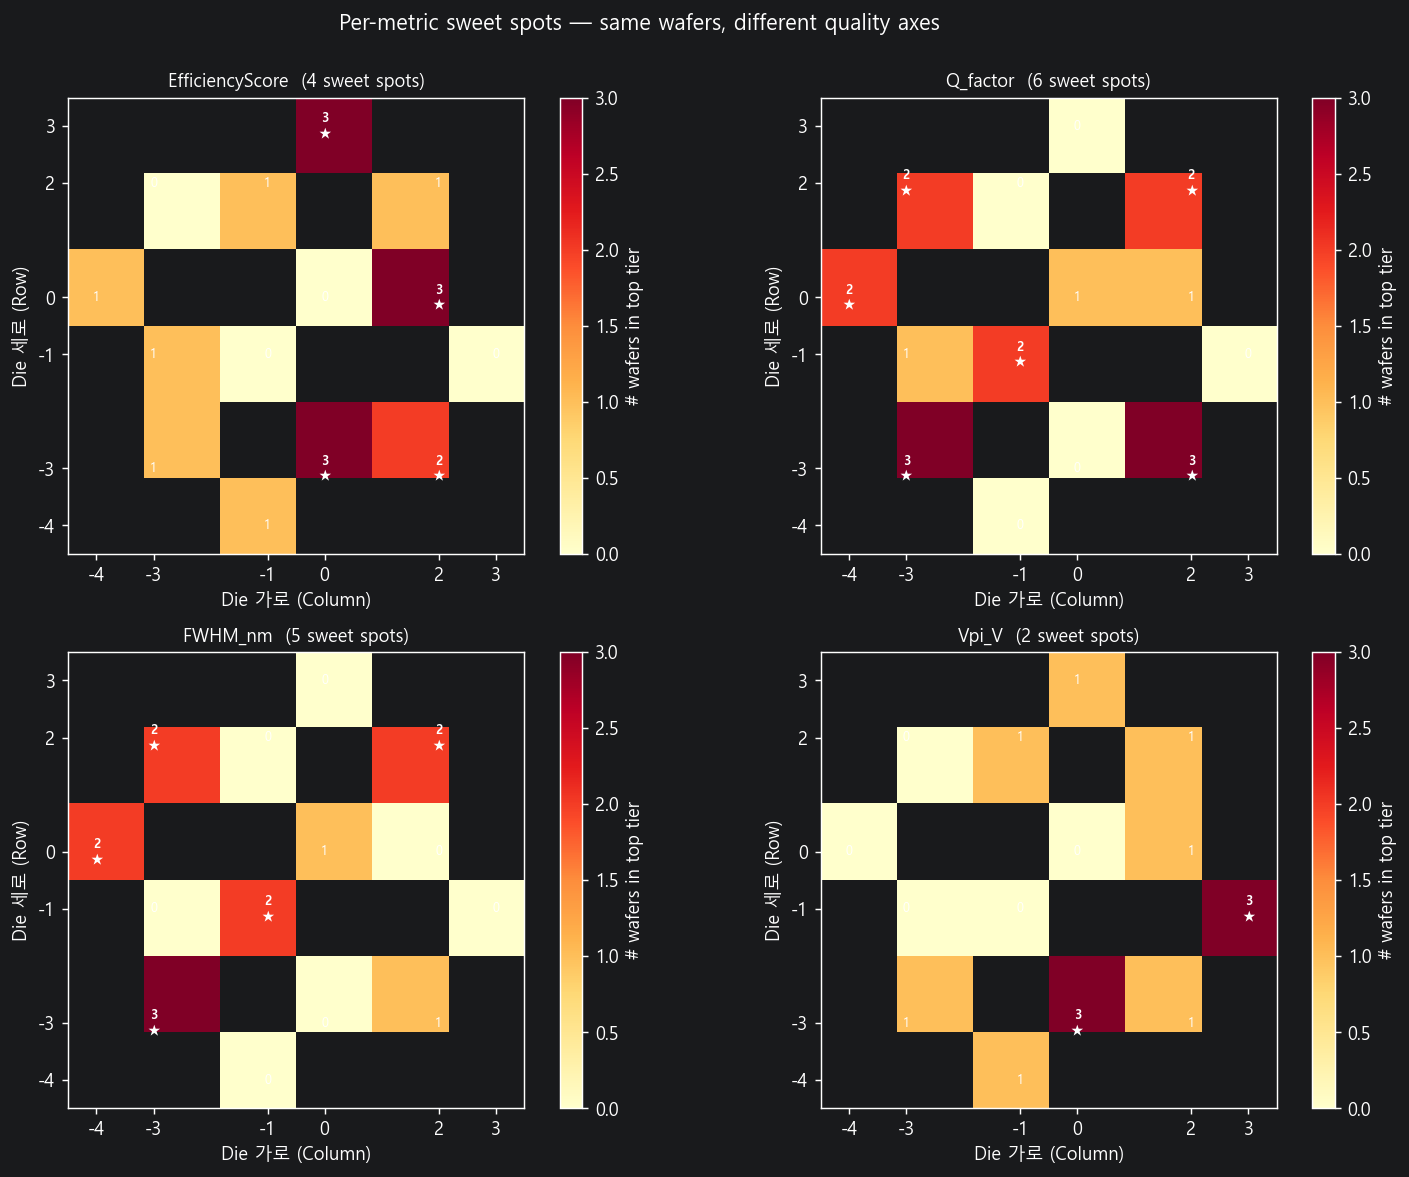

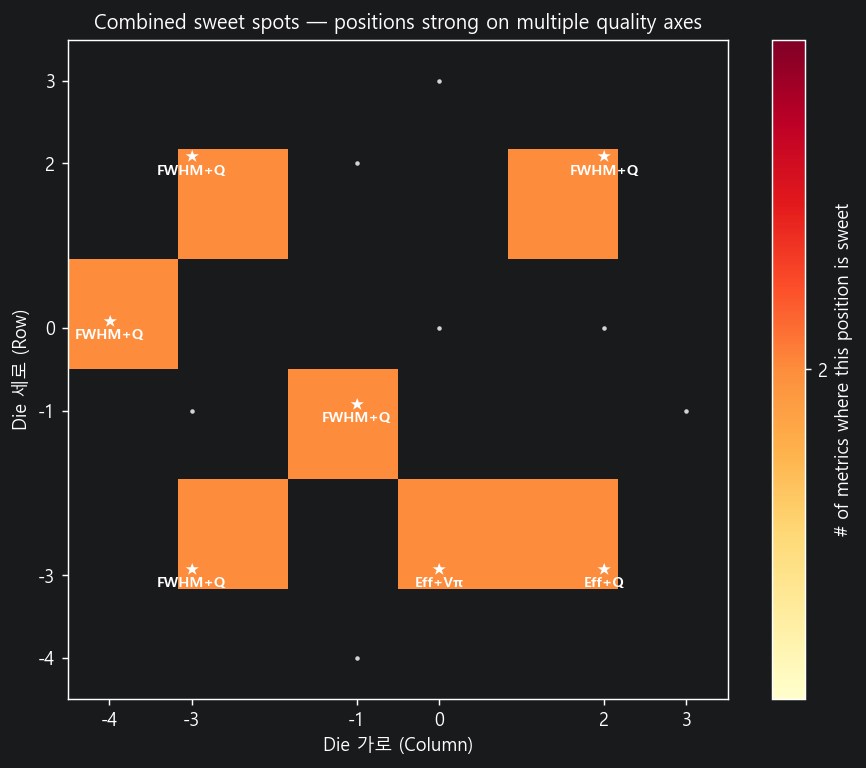

In [34]:
p1 = plot_multi_metric_sweet_spots(multi, FIG_DIR / 'multi_metric_sweet_spots.png')
p2 = plot_combined_sweet_spots(
    combined, FIG_DIR / 'combined_sweet_spots.png',
    all_die_positions=scored[['DieCol', 'DieRow']],
)

display(Image(filename=str(p1)))
display(Image(filename=str(p2)))

**주요 결과**:
- **(2, -3)**: `Eff + Q` — 종합 효율과 spectral selectivity 둘 다 좋음 → 가장 robust한 binning 후보
- **(0, -3)**: `Eff + Vπ` — 종합 효율과 변조 강도 둘 다 좋음
- **FWHM+Q 그룹** (5개): selectivity만 좋고 종합 효율은 평범 → 도파관 dimension은 좋지만 도핑이 부족한 위치

## 8. 시각화 — 모든 wafer map 일괄 생성

이 셀은 종합 리포트와 같은 그림들을 한 번에 만들어요. 시각화만 따로 보고 싶을 때 사용.

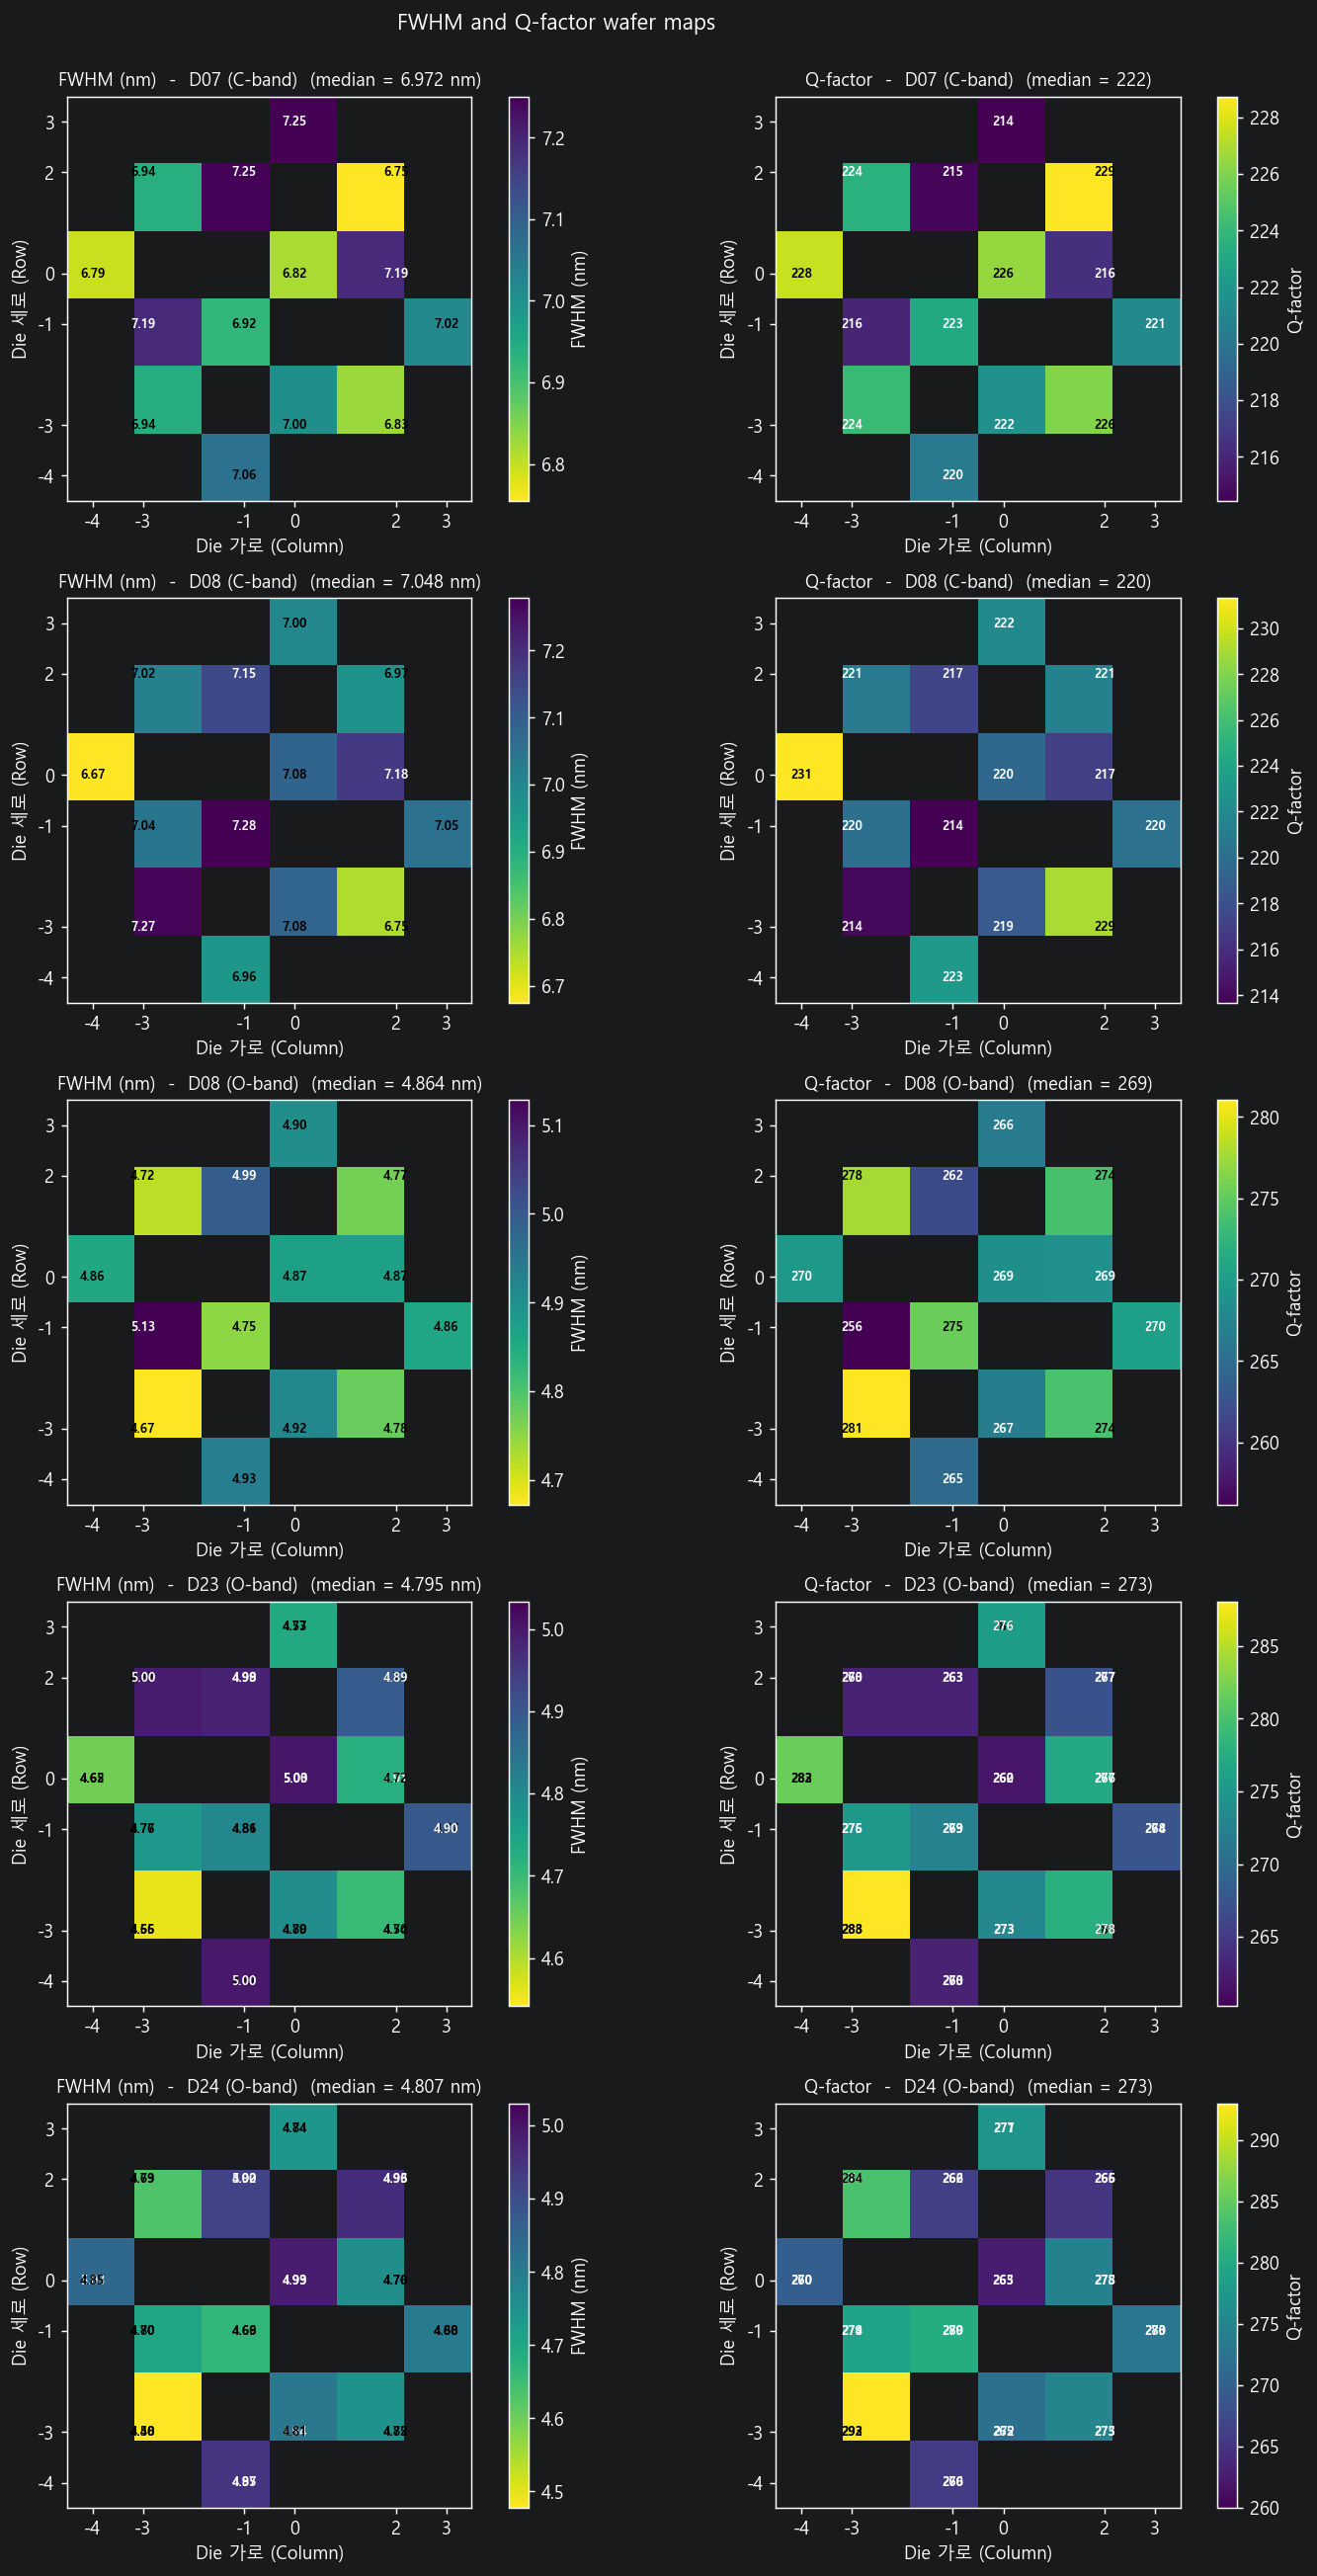

In [35]:
from picqa.viz.wafer_map import plot_fwhm_wafermap

p = plot_fwhm_wafermap(
    fwhm_df.dropna(subset=['Q_factor']),
    FIG_DIR / 'fwhm_wafermap.png',
    show_q=True, per_band_scale=True,
)
display(Image(filename=str(p)))

## 최종 요약

이 분석에서 도출된 핵심 결론:

### 1. Wafer는 두 그룹으로 명확히 나뉨
- **고성능**: D07, D08 (EfficiencyScore ≈ 0.7, Vπ ≈ 27V)
- **저성능**: D23, D24 (EfficiencyScore ≈ 0.35, Vπ ≈ 37V)
- PN 변조기 도핑 농도가 다른 batch일 가능성 (D07/D08: 강한 도핑, D23/D24: 약한 도핑)

### 2. 위치 패턴은 일관됨
- 모든 wafer에서 SE 사분면이 가장 좋고 SW가 가장 약함
- 공정 비대칭 (CMP, 노광, 식각 등) 가능성

### 3. Sweet spot 후보 (양산 binning에 활용)
| 위치 | 어떤 axis에서 좋은가 |
|---|---|
| **(2, -3)** | Efficiency + Q-factor (가장 robust) |
| **(0, -3)** | Efficiency + Vπ (변조 강도 우수) |
| (-3, -3), (-1, -1), (2, 2), (-4, 0), (-3, 2) | FWHM + Q (selectivity만 우수) |

### 4. 한계
- 4 wafer만으로는 통계적 검정력 제한적
- O-band spec으로 평가하므로 D07 (C-band 전용)의 yield는 0% (spec 부재일 뿐 die 자체는 정상)

## 다음 단계

- **자동 분석 한 번에**: `python run.py --data ./HY202103_data --out ./results`
- **종합 리포트 (Markdown + 그림)**: `picqa report ./HY202103_data --output-dir ./out --spec configs/mzm_spec.yaml --family mzm`
- **개별 die 빠른 조회**: `picqa show ./HY202103_data D08 "(0,0)" --band O --plot vpi_analysis`